<a href="https://colab.research.google.com/github/Adriungs/SQL/blob/main/SQL_INTERMEDIO/2_NULL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<center>
<font size = '4'><u><b>FRAGMENTACION DE DATAFRAME</b></u></font>
</center>

En este caso las explicaciónes de los codigos de python no son importantes,sin embargo, si voy a detallar que lo que hizo el codigo en python es crearme 3 tablas dividiendo el contenido del archivo.

 **¿Porque fragmentamos el dataframe?**

  Como necesitamos unir multiples tablas para futuras prácticas lo conveniente es dividirlo usando solo una base de datos.

Otras bases de datos podrian no estar correlacionadas y estaremos juntando datos diferentes ó que nada tienen que ver con lo que estamos analizando.

En las aplicaciones reales se usan multiples tablas de diferentes sectores eso es lo que hicimos al fragmentar.

Si lo pensamos en aplicaciones reales hay tres sectores que requieren diferentes tablas:


1.   Clientes
2.   Productos
3.   Ventas



In [ ]:
#Nueva base de datos
!pip install jupysql --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.1/95.1 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 192.8/192.8 kB 15.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 270.8/270.8 kB 19.4 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import sqlite3

# 1. Cargar el archivo con tus columnas reales
df_original = pd.read_csv('retail_ferreteria.csv')

# 2. Normalización ajustada a tu dataset

clientes = df_original[['id_cliente', 'nombre_cliente', 'provincia']].drop_duplicates()

productos = df_original[['producto', 'categoria', 'precio_unitario']].drop_duplicates()

ventas = df_original[['id_venta', 'fecha_hora', 'id_cliente', 'producto', 'cantidad', 'total_venta', 'sucursal', 'medio_pago']]

# 3. Guardar en el motor SQLite
conn = sqlite3.connect('ferreteria.db')

try:
  clientes.to_sql('clientes', conn, if_exists='replace', index=False)
  productos.to_sql('productos', conn, if_exists='replace', index=False)
  ventas.to_sql('ventas', conn, if_exists='replace', index=False)
finally:
    conn.close()  # <-- Esto libera el archivo y evita el error "database is locked"

print("¡Base de datos 'ferreteria.db' creada y liberada con éxito!")



¡Base de datos 'ferreteria.db' creada y liberada con éxito!


In [ ]:
%load_ext sql
%sql sqlite:///ferreteria.db
%config SqlMagic.feedback = False
%config SqlMagic.displaylimit = 0

Connecting to 'sqlite:///ferreteria.db'

<center>
<font size = '6' color =black><u><b>valores NULL<b/></u></font>
</center>

En SQL, NULL representa la ausencia de un valor o un dato desconocido. No significa cero, ni un espacio en blanco, ni una cadena vacía; es simplemente un marcador de posición para un valor que falta

<u><b>Cuándo y para qué se usa</b></u>

* Datos desconocidos: Cuando se registra un cliente pero aún no se sabe su segundo apellido.
* Datos no aplicables: El campo "fecha_de_divorcio" para una persona que es soltera.
* Valores opcionales: Información que el usuario puede elegir no llenar en un formulario.

###Con qué se usa (Filtrado de datos)

<u><b>La cláusula WHERE</b></u>

Se usa para filtrar las filas que cumplen una condición. Cuando trabajas con datos faltantes, WHERE se combina con los siguientes operadores:

1. IS NULL

Se utiliza para buscar filas donde un campo específico está vacío o no tiene valor asignado.

Ejemplo: Buscar empleados que no tienen un jefe asignado.

---

SELECT *

FROM empleados

WHERE id_jefe IS NULL;

---

2.IS NOT NULL

Se utiliza para excluir los valores vacíos y traer solo las filas que sí contienen datos válidos.

Ejemplo: Buscar clientes que sí registraron su correo electrónico.

---
SELECT *

FROM clientes

WHERE email IS NOT NULL;

---


###El formato es el siguiente:

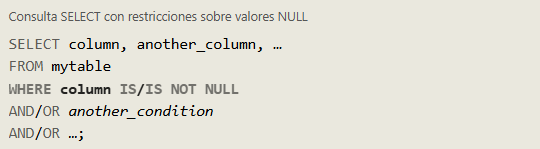

clientes = df_original[['id_cliente', 'nombre_cliente', 'provincia']].drop_duplicates()

productos = df_original[['producto', 'categoria', 'precio_unitario']].drop_duplicates()

ventas = df_original[['id_venta', 'fecha_hora', 'id_cliente', 'producto', 'cantidad', 'total_venta', 'sucursal', 'medio_pago']]


<center>
<font size = '6' color =black><u><b>EJERCICIOS<b/></u></font>
</center>

Encontrar nulos en las columnas

In [ ]:
%%sql
SELECT nombre_cliente , provincia
FROM clientes
WHERE nombre_cliente IS NULL OR provincia IS NULL;

nombre_cliente,provincia


In [ ]:
%%sql
SELECT producto, categoria, precio_unitario
FROM productos
WHERE producto IS NULL OR categoria IS NULL OR precio_unitario IS NULL;

producto,categoria,precio_unitario
Sierra circular,Herramientas eléctricas,None
Cinta métrica,Medición,None
Caja de tornillos,Fijaciones,None
Destornillador,Herramientas manuales,None
Guantes de trabajo,Protección personal,None
Martillo,Herramientas manuales,None
Rodillo de pintura,Accesorios pintura,None
Taladro eléctrico,Herramientas eléctricas,None
Llave inglesa,Herramientas manuales,None
Pintura látex 4L,Pinturas,None


Ahora que encontramos nulos en precios_unitarios fijemonos si fue comprado, por quien y en que fecha

In [ ]:
%%sql
SELECT c.id_cliente, c.nombre_cliente, v.fecha_hora, p.producto, p.precio_unitario
FROM clientes AS c
LEFT JOIN ventas AS v
  ON c.id_cliente = v.id_cliente
LEFT JOIN productos AS p
  ON v.producto = p.producto
WHERE p.precio_unitario IS NULL
LIMIT 15;

id_cliente,nombre_cliente,fecha_hora,producto,precio_unitario
2824,Benjamin Perez Diaz,2025-06-29 12:36:14,Caja de tornillos,None
2824,Benjamin Perez Diaz,2025-06-29 12:36:14,Caja de tornillos,None
2424,Amparo Paez Rodriguez,2025-02-27 08:47:28,Taladro eléctrico,None
7873,Martina Diaz Gimenez,2024-09-26 19:31:40,Sierra circular,None
5552,Sr(a). Thiago Agustin Quiroga,2025-02-26 10:24:10,Llave inglesa,None
5552,Sr(a). Thiago Agustin Quiroga,2025-08-17 13:49:12,Destornillador,None
5552,Sr(a). Thiago Agustin Quiroga,2025-08-17 13:49:12,Destornillador,None
5333,Tomàs Victoria Aguero,2025-07-08 04:47:31,Sierra circular,None
6925,Genaro Alma Fernandez,2025-07-10 00:28:32,Destornillador,None
7227,Santino Olivia Sosa Romero,2024-12-28 05:42:28,Sierra circular,None


Perfecto ya hicimos una estructura casi completa